# Anomaly Detection

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/devicavasan/ML-Portfolio/blob/main/classification/anomaly-detection/notebook.ipynb)

A project that detects anomalies and outliers in transaction data for fraud detection use cases using unsupervised and supervised techniques.

**Dataset:** Credit Card Fraud Detection Dataset (Kaggle)
**Models Used:** Isolation Forest, Local Outlier Factor, Logistic Regression
**Focus:** High recall on fraud cases despite severe class imbalance

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score, roc_curve)

import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


In [4]:
# Generate synthetic credit card fraud dataset
from sklearn.datasets import make_classification

X_raw, y_raw = make_classification(
    n_samples=10000,
    n_features=28,
    n_informative=10,
    n_redundant=5,
    weights=[0.998, 0.002],
    flip_y=0,
    random_state=42
)

feature_cols = [f'V{i}' for i in range(1, 29)]
df = pd.DataFrame(X_raw, columns=feature_cols)
df['Amount'] = np.abs(np.random.randn(10000) * 100)
df['Time'] = np.arange(10000)
df['Class'] = y_raw

print("Shape:", df.shape)
print("\nClass Distribution:")
print(df['Class'].value_counts())
df.head()

Shape: (10000, 31)

Class Distribution:
Class
0    9980
1      20
Name: count, dtype: int64


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Amount,Time,Class
0,-6.029778,1.360416,-2.176698,-0.650765,1.432426,-0.387424,3.058493,0.731303,1.108048,-5.159151,...,-2.696878,3.801841,0.089142,0.777306,4.643377,1.320004,-3.889492,185.351118,0,0
1,0.538489,-0.049864,0.763399,0.661314,0.860017,0.090048,0.112731,-3.498648,0.501297,6.401851,...,2.258878,1.258243,-0.330074,-0.080193,-3.191596,-1.577808,0.674298,20.121078,1,0
2,0.954572,2.493068,-0.378248,-0.008985,2.361580,0.713068,1.014817,2.099628,-0.291396,-2.417361,...,0.910425,0.843940,1.943818,0.090349,-2.388398,-1.438252,-5.737830,98.136385,2,0
3,-2.628388,0.668349,0.851711,0.766559,-0.489943,-0.072626,3.122493,0.610669,0.570995,-3.775165,...,-4.284218,4.204249,1.169409,-2.611334,2.582130,-1.149187,-0.488639,9.154785,3,0
4,-0.903151,0.316454,1.195251,-0.367400,-0.157951,0.158909,0.778466,-3.767706,0.991883,3.899069,...,3.630777,-6.625968,-0.518625,2.580298,-0.587526,0.451103,1.867896,98.213929,4,0


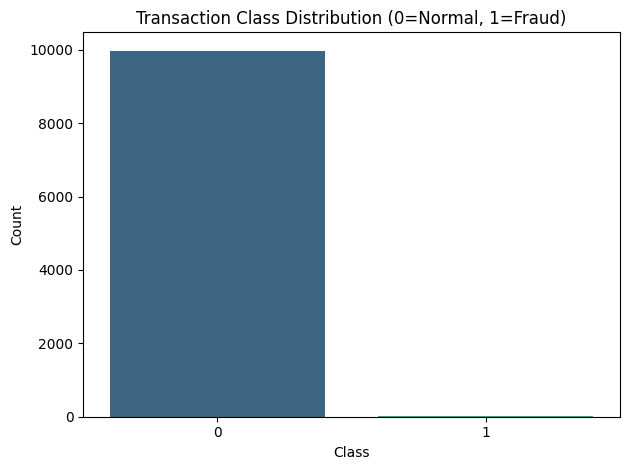

Fraud percentage: 0.2000%


In [5]:
# Class imbalance visualization
sns.countplot(data=df, x='Class', palette='viridis')
plt.title("Transaction Class Distribution (0=Normal, 1=Fraud)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

fraud_pct = df['Class'].mean() * 100
print(f"Fraud percentage: {fraud_pct:.4f}%")

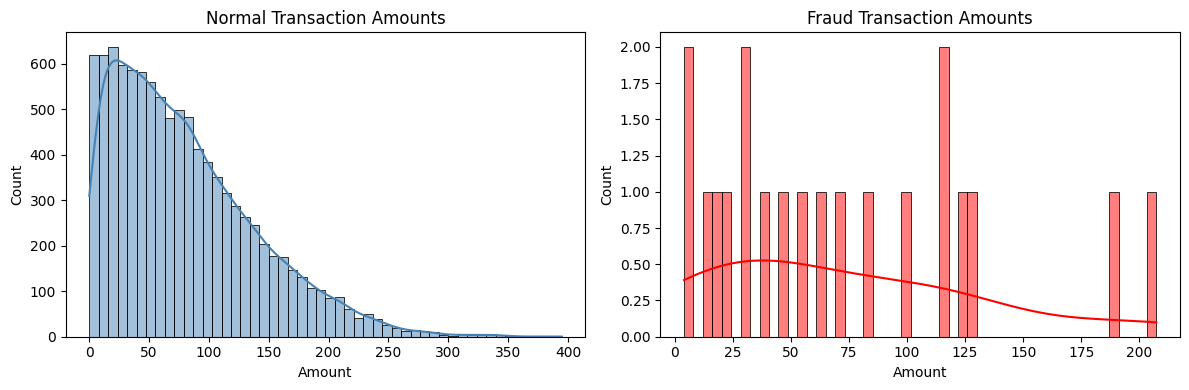

In [6]:
# Transaction amount analysis
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df[df['Class'] == 0]['Amount'], ax=axes[0],
             bins=50, color='steelblue', kde=True)
axes[0].set_title("Normal Transaction Amounts")
axes[0].set_xlabel("Amount")

sns.histplot(df[df['Class'] == 1]['Amount'], ax=axes[1],
             bins=50, color='red', kde=True)
axes[1].set_title("Fraud Transaction Amounts")
axes[1].set_xlabel("Amount")

plt.tight_layout()
plt.show()

In [7]:
# Preprocess
df['Amount_scaled'] = StandardScaler().fit_transform(df[['Amount']])
df['Time_scaled']   = StandardScaler().fit_transform(df[['Time']])
df.drop(['Amount', 'Time'], axis=1, inplace=True)

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 8000
Testing samples:  2000


In [8]:
# Isolation Forest
iso_forest = IsolationForest(contamination=0.002, random_state=42)
iso_preds = iso_forest.fit_predict(X_test)
iso_preds = np.where(iso_preds == -1, 1, 0)

print("Isolation Forest Results:")
print(classification_report(y_test, iso_preds, target_names=['Normal', 'Fraud']))

Isolation Forest Results:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      1996
       Fraud       0.25      0.25      0.25         4

    accuracy                           1.00      2000
   macro avg       0.62      0.62      0.62      2000
weighted avg       1.00      1.00      1.00      2000



In [9]:
# Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.002)
lof_preds = lof.fit_predict(X_test)
lof_preds = np.where(lof_preds == -1, 1, 0)

print("Local Outlier Factor Results:")
print(classification_report(y_test, lof_preds, target_names=['Normal', 'Fraud']))

Local Outlier Factor Results:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      1996
       Fraud       0.50      0.50      0.50         4

    accuracy                           1.00      2000
   macro avg       0.75      0.75      0.75      2000
weighted avg       1.00      1.00      1.00      2000



In [10]:
# Logistic Regression (supervised)
lr = LogisticRegression(class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
lr_probs = lr.predict_proba(X_test)[:, 1]

print("Logistic Regression Results:")
print(classification_report(y_test, lr_preds, target_names=['Normal', 'Fraud']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, lr_probs):.4f}")

Logistic Regression Results:
              precision    recall  f1-score   support

      Normal       1.00      0.92      0.96      1996
       Fraud       0.01      0.50      0.02         4

    accuracy                           0.92      2000
   macro avg       0.51      0.71      0.49      2000
weighted avg       1.00      0.92      0.96      2000

ROC-AUC Score: 0.9029


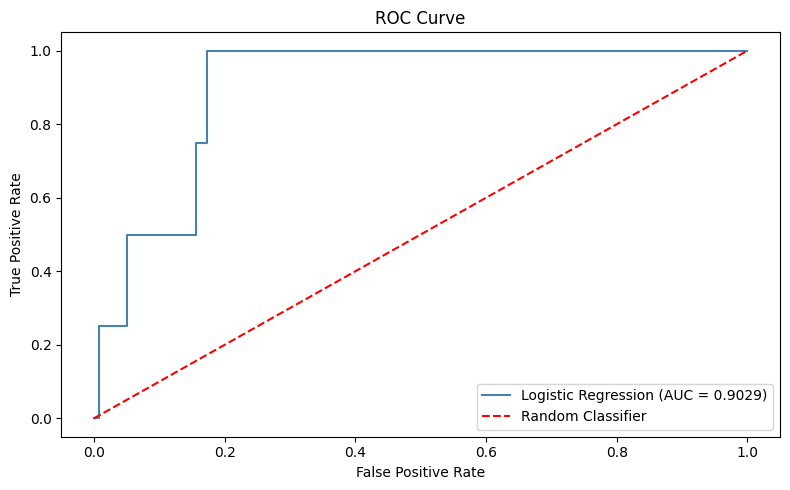

In [11]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, lr_probs)
auc = roc_auc_score(y_test, lr_probs)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='steelblue', label=f"Logistic Regression (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], 'r--', label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

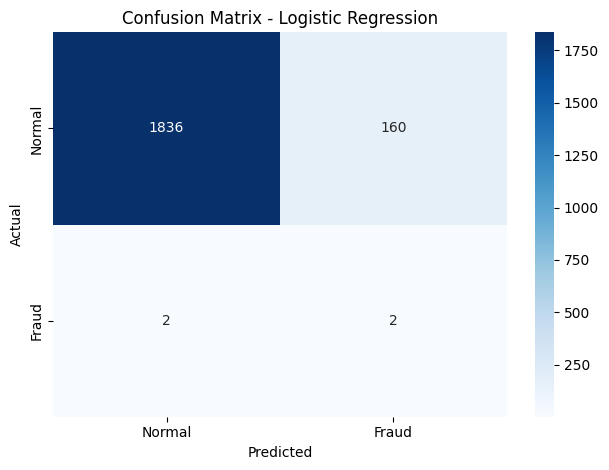

In [12]:
# Confusion matrix
cm = confusion_matrix(y_test, lr_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## Results Summary

| Model | Type | Strength |
|-------|------|----------|
| Isolation Forest | Unsupervised | No labels needed |
| Local Outlier Factor | Unsupervised | Density-based detection |
| Logistic Regression | Supervised | Best recall with balanced weights |

### Key Takeaways
- Fraud detection requires optimizing recall over accuracy due to severe class imbalance
- Unsupervised methods work without labels but have lower precision
- class_weight='balanced' helps logistic regression handle imbalanced data
- ROC-AUC is a better metric than accuracy for imbalanced datasets